# Layer Normalization layer

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(
    nn.Linear(5,6),
    nn.ReLU(),
)
output = layer(batch_example)
print(output)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [2]:
mean = output.mean(dim=-1, keepdim=True)
var = output.var(dim=-1, keepdim=True, unbiased=False)
print("Mean:", mean)
print("Variance:", var)

Mean: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance: tensor([[0.0192],
        [0.0332]], grad_fn=<VarBackward0>)


In [3]:
output_normalized = (output - mean) / torch.sqrt(var + 1e-5)
mean_normalized = output_normalized.mean(dim=-1, keepdim=True)
var_normalized = output_normalized.var(dim=-1, keepdim=True, unbiased=False)
print("Mean of normalized output:", mean_normalized)
print("Variance of normalized output:", var_normalized)
print("Normalized output:", output_normalized)

Mean of normalized output: tensor([[0.0000e+00],
        [3.9736e-08]], grad_fn=<MeanBackward1>)
Variance of normalized output: tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)
Normalized output: tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<DivBackward0>)


In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))


    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_normalized + self.shift

In [6]:
ln = LayerNorm(5)
output_ln = ln(batch_example)
mean = output_ln.mean(dim=-1, keepdim=True)
var = output_ln.var(dim=-1, keepdim=True, unbiased=False)
print("Mean after LayerNorm:", mean)
print("Variance after LayerNorm:", var)

Mean after LayerNorm: tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after LayerNorm: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# GeLU Activation

In [18]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Converting x into tensor if it's not already a tensor
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

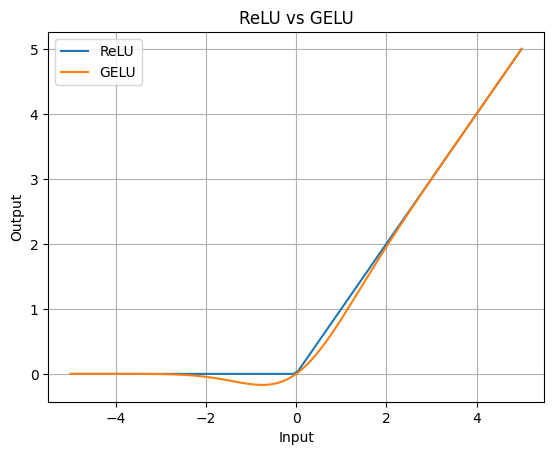

In [19]:
# Compare ReLU and GELU
import matplotlib.pyplot as plt
x = torch.linspace(-5, 5, 100)
relu = nn.ReLU()
gelu = GELU()
plt.plot(x, relu(x).numpy(), label='ReLU')
plt.plot(x, gelu(x).numpy(), label='GELU')
plt.legend()
plt.title("ReLU vs GELU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()




In [25]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layer(x)

In [26]:
config = {
    "emb_dim": 768
}
ff = FeedForward(config)
x = torch.randn(2, 3, 768)
output_ff = ff(x)
print("Output of FeedForward layer:", output_ff.shape)

Output of FeedForward layer: torch.Size([2, 3, 768])


In [24]:
config.keys()

dict_keys(['emb_dim'])